In [1]:
# Step 1: Mount your Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
 #Step 2: Navigate to where you saved the file
model_path = '/content/drive/MyDrive/Effnet Adverserial_Training/EfficientNetB1.keras'

# Step 3: Load the model
from tensorflow.keras.models import load_model
model = load_model(model_path)

print("Model loaded successfully!")

Model loaded successfully!


In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd

def compute_output_grads(model, image):
    """
    Compute the element-wise grads matrix of the model output with respect to the input image.
    Args:
        input image with dimensions: [H, W, C]
        tf model
    """
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(image)
        output = model(tf.expand_dims(image, axis=0))  # Forward pass
    element_wise_grad = tape.jacobian(output, image, experimental_use_pfor=True)
    return tf.squeeze(element_wise_grad, axis=0)  # Remove batch dimension

def saliency_map(jacobian, target_label):
    """
    Compute the saliency map to determine which pixels to perturb.
    Args:
        the element-wise gradients matrix
        the targetted label
    """
     # Get gradient for target class [H, W, C]
    J_t = jacobian[target_label]

    # Sum gradients for all other classes [H, W, C]
    sum_J_other = tf.reduce_sum(jacobian, axis=0) - J_t

    # Compute conditions
    cond1 = J_t < 0                          # Condition 1: J_t < 0
    cond2 = sum_J_other > 0                  # Condition 2: Sum of other grads > 0
    zero_mask = tf.logical_or(cond1, cond2)  # Where to set saliency to 0

    # Compute saliency values
    saliency_values = J_t * tf.abs(sum_J_other)

    # Apply conditions
    saliency_map = tf.where(zero_mask,
                          tf.zeros_like(saliency_values),
                          saliency_values)

    return saliency_map

def jsma_attack_v2(model, image, target_label, gamma, theta, num_pixels):
    """
    Performs a JSMA attack on multi-class classification model.

    Args:
        model: The TensorFlow/Keras model.
        image: The input image (tensor of shape [H, W, C]) (un-normalized).
        target_label: The desired class output (class id).
        theta: The perturbation step size.
        gamma: Maximum total distortion (percentage of modified pixels).
        num_pixels: Number of pixels to perturb at each iteration.

    Returns:
        The adversarial image.
    """
    adversarial = tf.identity(image)
    itr = 0
    distortion = 0.0
    class_id = 0
    # print initial prediction
    pred = model(tf.expand_dims(image, axis=0))
    class_id = np.argmax(pred)
    print(f"prediction before attack: {class_id}")

    while distortion < gamma and class_id != target_label and itr < 15: # stop if maximum distortion reached or attack succeeded or max. num. of iterartions reached
        # step 1: Compute the output grads with respect to input image
        grads = compute_output_grads(model, adversarial)

        # step 2: Compute saliency map to perturb most important pixels
        saliency = saliency_map(grads, target_label)

        # step 3: Get maximum pixels value to perturb.
        # Flatten the saliency map to 1D and get top N values/indices
        flat_saliency = tf.reshape(saliency, [-1])  # Shape [H*W*C]
        top_values, flat_indices = tf.math.top_k(flat_saliency, k=num_pixels)
        # Convert flat indices to 3D coordinates (h, w, c)
        h = flat_indices // (saliency.shape[1] * saliency.shape[2])
        remainder = flat_indices % (saliency.shape[1] * saliency.shape[2])
        w = remainder // saliency.shape[2]
        c = remainder % saliency.shape[2]

        # Stack into [N, 3] tensor
        top_indices = tf.stack([h, w, c], axis=1)

        # Create updates tensor (shape [N])
        updates = tf.ones([tf.shape(top_indices)[0]]) * theta

        # Apply scatter add operation
        adversarial = tf.tensor_scatter_nd_add(
            adversarial,
            top_indices,  # [N, 3] indices
            updates       # [N] values to add
        )
        # Clip to maintain constraints
        adversarial = tf.clip_by_value(adversarial, 0, 255)

        # Check if misclassification occurs
        pred = model(tf.expand_dims(adversarial, axis=0))
        class_id = np.argmax(pred)
        print(f"current prediction : {class_id}")
        if (class_id == target_label):
            print(f"Attacked successfully, predicted class: {class_id}")

        itr+=1
    if (class_id != target_label):
        print(f"Attack failed :(")
    return adversarial





In [5]:
from myutils import display_ppm_image, convert_jfif_to_ppm,predict_traffic_sign_all
from GTSRB_utils import GTSRB_CLASSES, predict_traffic_sign, create_subset_loader, load_ppm_image

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
def load_input_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, [240, 240])
    img = tf.cast(img, tf.float32)  # Keep unnormalized
    img = tf.expand_dims(img, axis=0)  # (1, 240, 240, 3)
    return img
def show_image_clean(image_tensor):
    # Remove batch dimension only if it exists
    if len(image_tensor.shape) == 4:
        image_tensor = image_tensor[0]

    image_np = tf.clip_by_value(image_tensor, 0, 255).numpy().astype(np.uint8)

    # Display
    plt.imshow(image_np)
    plt.axis('off')
    plt.title("Clean Image")
    plt.show()
def load_image_as_tensor(image_path, target_size=(240, 240)):
    """
    Loads a .ppm, .jfif, .jpg, or .png image file and returns a tensor of shape (1, H, W, 3)
    with dtype float32 in [0, 255] range (unnormalized).

    Args:
        image_path (str): File path to image.
        target_size (tuple): Desired output size (H, W) for the model.

    Returns:
        Tensor of shape (1, H, W, 3) ready for prediction.
    """
    image_data = tf.io.read_file(image_path)
    img = tf.image.decode_image(image_data, channels=3, expand_animations=False)  # handles ppm, jfif, etc.
    img = tf.image.resize(img, target_size)
    img = tf.cast(img, tf.float32)  # Keep unnormalized as your model expects [0, 255]
    img = tf.expand_dims(img, axis=0)  # Add batch dimension
    return img
def show_image_adverserial(image_tensor):
    # Remove batch dimension only if it exists
    if len(image_tensor.shape) == 4:
        image_tensor = image_tensor[0]

    image_np = tf.clip_by_value(image_tensor, 0, 255).numpy().astype(np.uint8)

    # Display
    plt.imshow(image_np)
    plt.axis('off')
    plt.title("Adverserial Image")
    plt.show()

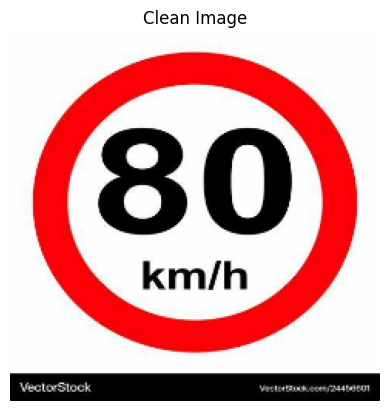

New shape: (240, 240, 3)
prediction before attack: 5
current prediction : 2
Attacked successfully, predicted class: 2


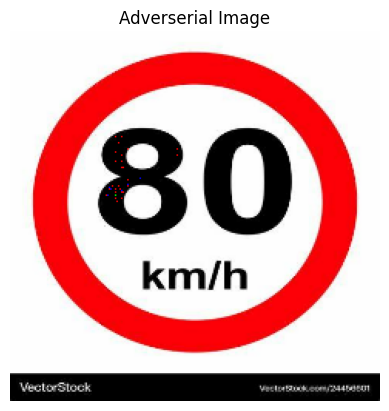

In [28]:
input_path=("/content/Limit80v2.jfif")
tensor_img=load_image_as_tensor(input_path)
show_image_clean(tensor_img)
image = tf.squeeze(tensor_img, axis=0)  # Now shape: (240, 240, 3)
print("New shape:", image.shape)
adv_img = jsma_attack_v2(model, image,target_label= 2,gamma = 0.1, theta = 255,num_pixels = 50)
show_image_adverserial(adv_img)

# Testing Another image

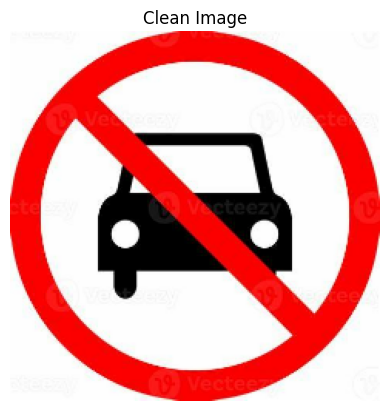

New shape: (240, 240, 3)
prediction before attack: 16
current prediction : 16
current prediction : 10
Attacked successfully, predicted class: 10


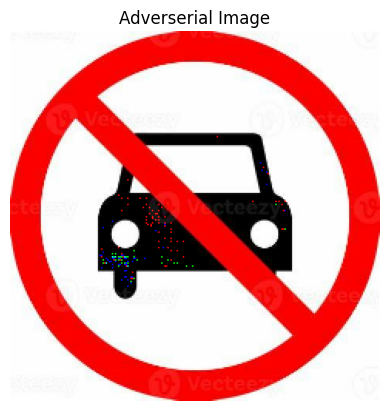

In [35]:
input_path=("/content/Novehicle.jfif")
tensor_img_v2=load_image_as_tensor(input_path)
show_image_clean(tensor_img_v2)
image_novehicle = tf.squeeze(tensor_img_v2, axis=0)  # Now shape: (240, 240, 3)
print("New shape:", image_novehicle.shape)
adv_img_no_vechile = jsma_attack_v2(model, image_novehicle,target_label= 10,gamma = 0.1, theta = 255,num_pixels = 100)
show_image_adverserial(adv_img_no_vechile )

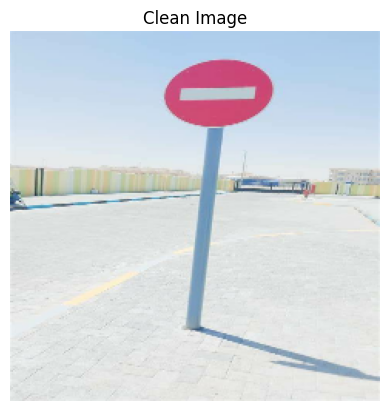

New shape: (240, 240, 3)
prediction before attack: 5
current prediction : 5
current prediction : 5
current prediction : 5
current prediction : 5
current prediction : 5
current prediction : 5
current prediction : 5
current prediction : 5
current prediction : 5
current prediction : 5
current prediction : 5
current prediction : 5
current prediction : 5
current prediction : 5
current prediction : 5
Attack failed :(


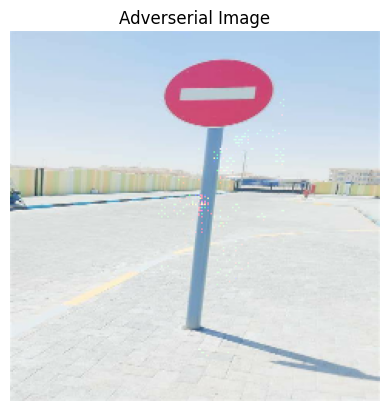

In [36]:
input_path=("/content/No.jfif")
tensor_img_v2=load_image_as_tensor(input_path)
show_image_clean(tensor_img_v2)
image_novehicle = tf.squeeze(tensor_img_v2, axis=0)  # Now shape: (240, 240, 3)
print("New shape:", image_novehicle.shape)
adv_img_no_vechile = jsma_attack_v2(model, image_novehicle,target_label= 17,gamma = 0.2, theta = 255,num_pixels = 50)
show_image_adverserial(adv_img_no_vechile )

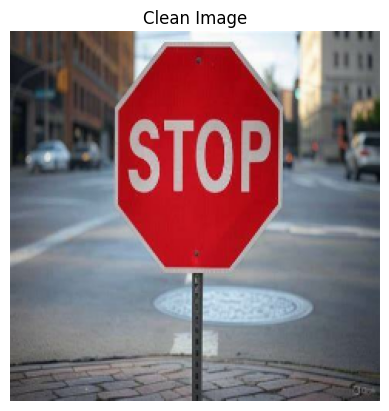

New shape: (240, 240, 3)
prediction before attack: 14
current prediction : 14
current prediction : 17
Attacked successfully, predicted class: 17


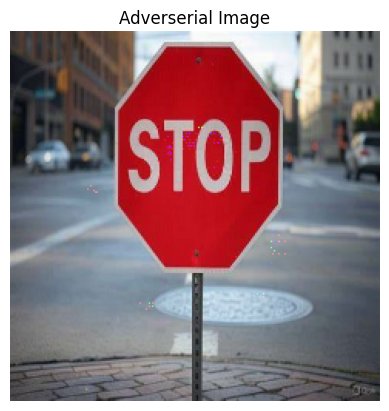

In [39]:
input_path=("/content/stopdct.jfif")
tensor_img_v2=load_image_as_tensor(input_path)
show_image_clean(tensor_img_v2)
image_novehicle = tf.squeeze(tensor_img_v2, axis=0)  # Now shape: (240, 240, 3)
print("New shape:", image_novehicle.shape)
adv_img_no_vechile = jsma_attack_v2(model, image_novehicle,target_label= 17,gamma = 0.2, theta = 255,num_pixels = 50)
show_image_adverserial(adv_img_no_vechile )